In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [146]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
churn_data = pd.read_csv('Customer-Churn-Records.csv')

In [3]:
df = churn_data.copy()

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [9]:
print(f'Categorical Type: {df.select_dtypes(include='object').columns}')
print(f'Total : {len(df.select_dtypes(include='object').columns)}')
print('\n')
print(f'Numerical Type: {df.select_dtypes(exclude='object').columns}')
print(f'Total : {len(df.select_dtypes(exclude='object').columns)}')


Categorical Type: Index(['Surname', 'Geography', 'Gender', 'Card Type'], dtype='object')
Total : 4


Numerical Type: Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='object')
Total : 14


In [10]:
drop_feature = ['Surname', 'RowNumber', 'CustomerId']
df = df.drop(drop_feature, axis=1)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [14]:
categorical_col = df.select_dtypes(include='object').columns
numerical_col = df.select_dtypes(exclude='object').columns

for col in categorical_col:
    print(f'{col} : {df[col].unique()}')
    print(f'Total Unique of {col}: {df[col].nunique()}\n')

Geography : ['France' 'Spain' 'Germany']
Total Unique of Geography: 3

Gender : ['Female' 'Male']
Total Unique of Gender: 2

Card Type : ['DIAMOND' 'GOLD' 'SILVER' 'PLATINUM']
Total Unique of Card Type: 4



## One Hot Encoding

In [16]:
from sklearn.preprocessing import OneHotEncoder
oh_encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
for col in categorical_col:
    df = pd.concat([
        df.drop(col, axis=1),
        oh_encoder.fit_transform(df[[col]])
    ], axis=1)

In [17]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,...,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,1,...,464,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,...,456,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,...,377,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,0,...,350,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,...,425,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [18]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Point Earned', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male',
       'Card Type_DIAMOND', 'Card Type_GOLD', 'Card Type_PLATINUM',
       'Card Type_SILVER'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Age                 10000 non-null  int64  
 2   Tenure              10000 non-null  int64  
 3   Balance             10000 non-null  float64
 4   NumOfProducts       10000 non-null  int64  
 5   HasCrCard           10000 non-null  int64  
 6   IsActiveMember      10000 non-null  int64  
 7   EstimatedSalary     10000 non-null  float64
 8   Exited              10000 non-null  int64  
 9   Complain            10000 non-null  int64  
 10  Satisfaction Score  10000 non-null  int64  
 11  Point Earned        10000 non-null  int64  
 12  Geography_France    10000 non-null  float64
 13  Geography_Germany   10000 non-null  float64
 14  Geography_Spain     10000 non-null  float64
 15  Gender_Female       10000 non-null  float64
 16  Gende

## Oversampling: SMOT

In [24]:
from imblearn.over_sampling import SMOTE
X = df.drop('Exited', axis=1)
y = df['Exited']

smote = SMOTE(random_state=0)
X_sample, y_sample = smote.fit_resample(X, y)


In [29]:
df2 = pd.DataFrame(X_sample, columns=df.drop('Exited', axis=1).columns)
df2['Exited'] = y_sample

In [31]:
df2.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Complain', 'Satisfaction Score',
       'Point Earned', 'Geography_France', 'Geography_Germany',
       'Geography_Spain', 'Gender_Female', 'Gender_Male', 'Card Type_DIAMOND',
       'Card Type_GOLD', 'Card Type_PLATINUM', 'Card Type_SILVER', 'Exited'],
      dtype='object')

In [42]:
df['Card Type_SILVER'].value_counts()

Card Type_SILVER
0.0    7504
1.0    2496
Name: count, dtype: int64

In [64]:
for i, col in enumerate(numerical_col):
    print(i, col)

0 CreditScore
1 Age
2 Tenure
3 Balance
4 NumOfProducts
5 HasCrCard
6 IsActiveMember
7 EstimatedSalary
8 Exited
9 Complain
10 Satisfaction Score
11 Point Earned


In [90]:
df2.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,...,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited
CreditScore,1.000000,-0.015980,0.020774,0.008726,0.018274,-0.001804,0.024265,-0.024742,-0.041361,0.008556,...,-0.008392,0.003693,0.005876,-0.000668,0.000668,0.001292,0.008958,0.001148,-0.011339,-0.040670
Age,-0.015980,1.000000,-0.039029,0.041211,-0.085155,-0.070830,-0.048233,-0.002495,0.357239,-0.052064,...,-0.048434,0.075546,-0.025859,0.055786,-0.055786,0.005024,-0.001699,0.008859,-0.012181,0.358200
Tenure,0.020774,-0.039029,1.000000,-0.002870,0.038492,0.031698,0.013063,0.022038,-0.074004,0.011393,...,0.015089,-0.013777,-0.002699,-0.017669,0.017669,-0.008113,0.026785,-0.022775,0.004229,-0.074180
Balance,0.008726,0.041211,-0.002870,1.000000,-0.233134,-0.026091,-0.042331,0.006638,0.136233,-0.022431,...,-0.275600,0.440564,-0.158926,-0.010729,0.010729,0.018767,-0.006617,-0.008806,-0.003453,0.136639
NumOfProducts,0.018274,-0.085155,0.038492,-0.233134,1.000000,0.047783,0.103962,0.016558,-0.213328,0.040433,...,0.037583,-0.059042,0.020530,-0.008249,0.008249,-0.016056,0.001304,0.021568,-0.006712,-0.215073
HasCrCard,-0.001804,-0.070830,0.031698,-0.026091,0.047783,1.000000,0.077749,-0.022067,-0.167840,0.025897,...,0.020255,-0.019952,-0.002016,-0.037825,0.037825,0.001829,-0.016086,0.011537,0.002645,-0.167680
IsActiveMember,0.024265,-0.048233,0.013063,-0.042331,0.103962,0.077749,1.000000,-0.016140,-0.374871,0.065215,...,0.047389,-0.071882,0.023059,-0.059108,0.059108,-0.018524,0.014325,-0.002449,0.006774,-0.377107
EstimatedSalary,-0.024742,-0.002495,0.022038,0.006638,0.016558,-0.022067,-0.016140,1.000000,0.012974,-0.003096,...,0.000679,-0.009162,0.009293,0.015614,-0.015614,-0.009617,0.002166,-0.014779,0.022224,0.013369
Complain,-0.041361,0.357239,-0.074004,0.136233,-0.213328,-0.167840,-0.374871,0.012974,1.000000,-0.127278,...,-0.138457,0.212341,-0.069933,0.146844,-0.146844,0.020361,-0.019335,0.000661,-0.001854,0.996609
Satisfaction Score,0.008556,-0.052064,0.011393,-0.022431,0.040433,0.025897,0.065215,-0.003096,-0.127278,1.000000,...,0.026050,-0.034470,0.007117,-0.018641,0.018641,-0.012640,0.014752,-0.002533,0.000537,-0.129354


<Axes: >

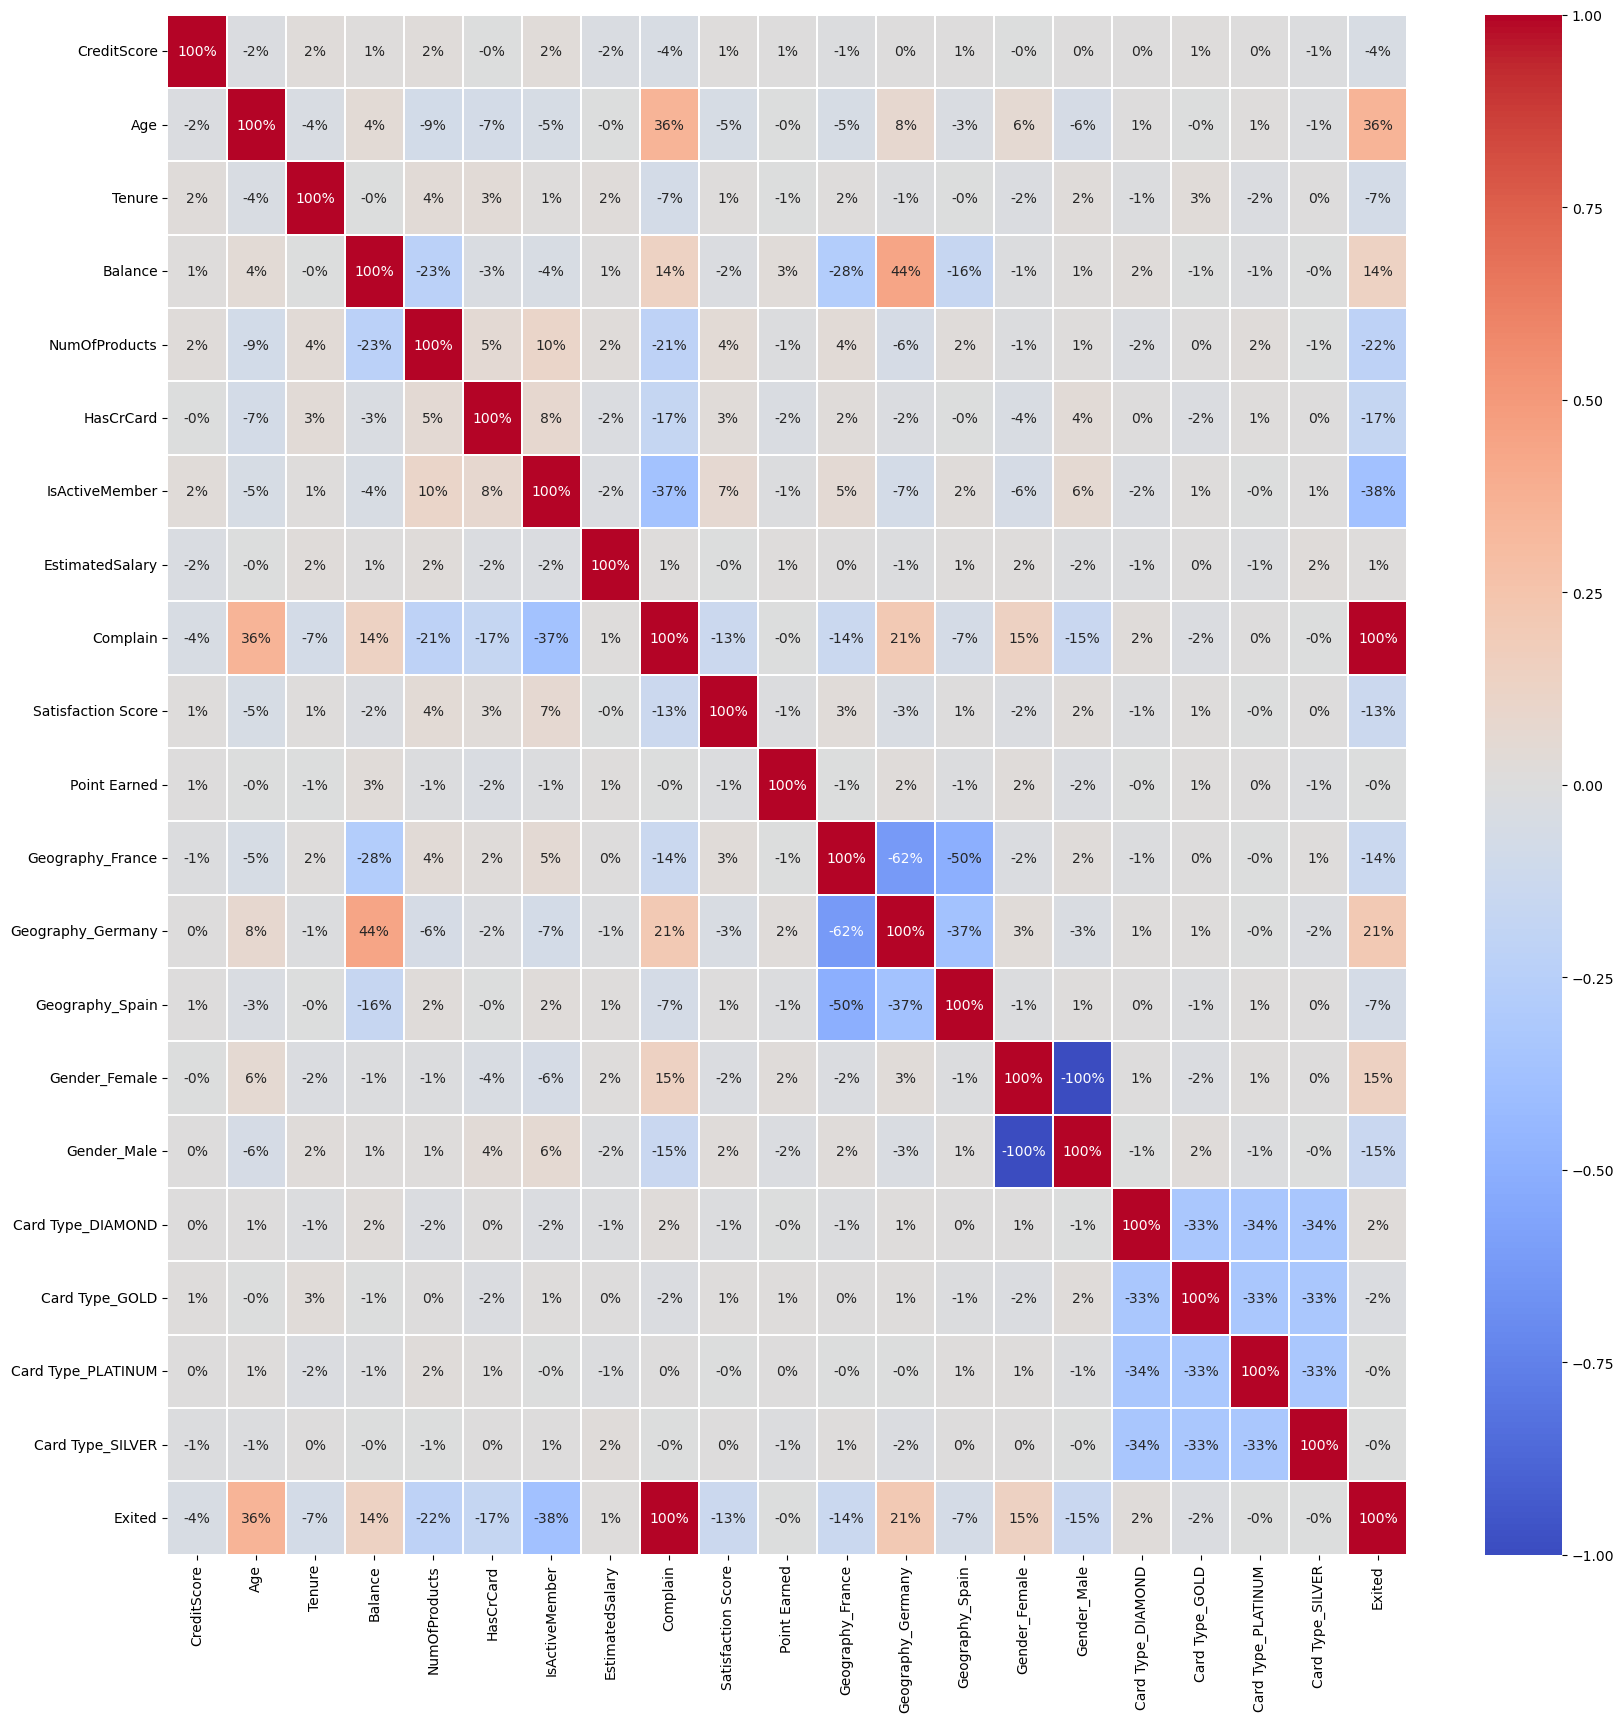

In [92]:
plt.figure(figsize=[20, 20])
sns.heatmap(df2.corr(),
           fmt='.0%',
           annot=True,
           cmap='coolwarm',
           lw=.2)

### ตรวจสอบ Distribution

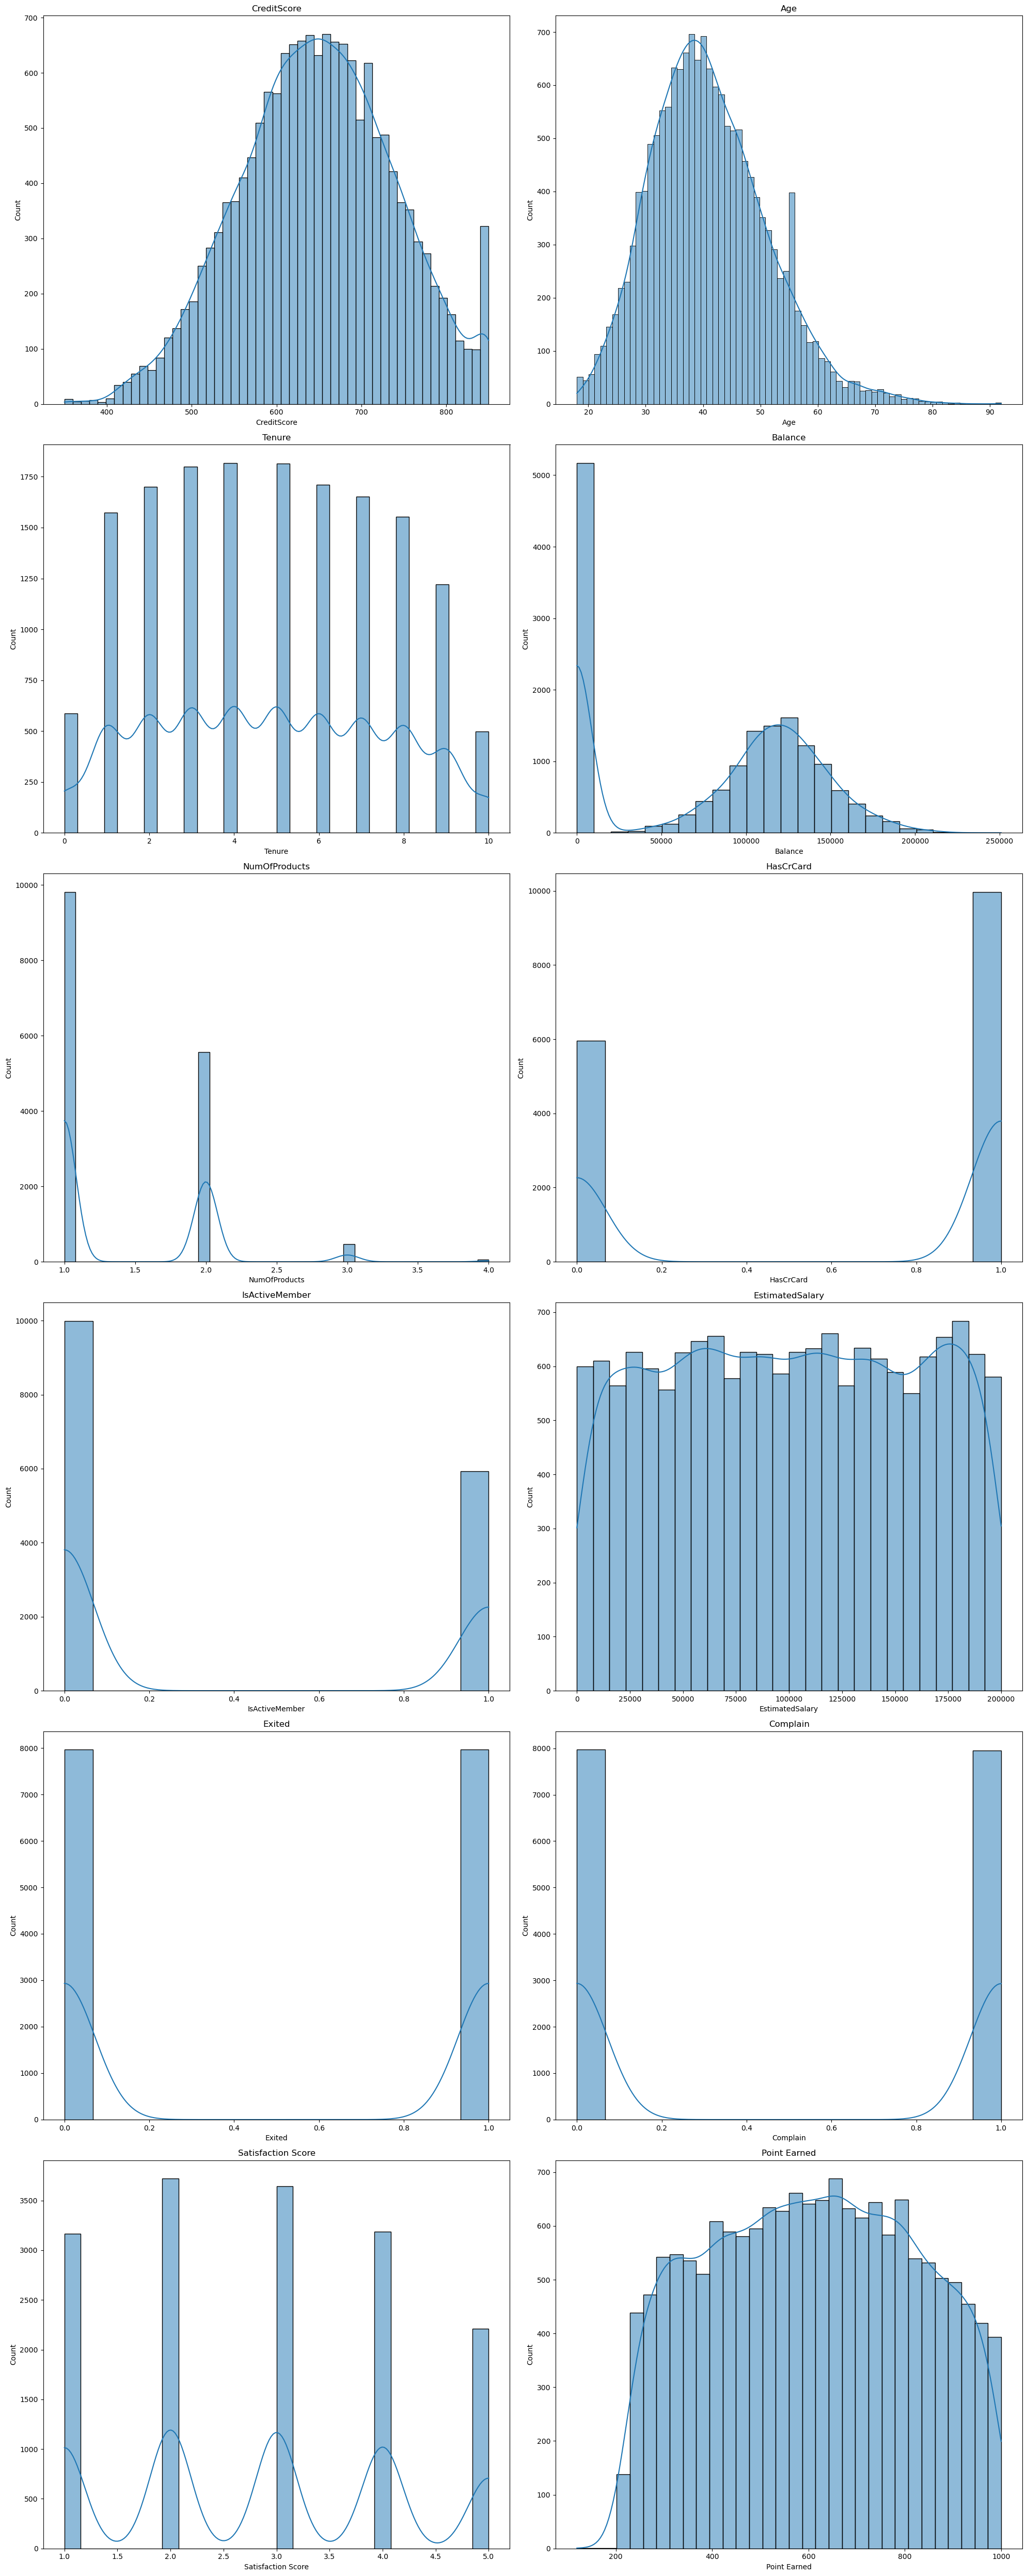

In [87]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.histplot(df2[column],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

In [88]:
df2[numerical_col].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000,15924.000000
mean,648.128109,41.009671,4.830884,81122.932684,1.421188,0.625973,0.372331,100497.030667,0.500000,0.499560,2.846333,606.102550
std,91.218563,10.055047,2.721810,61332.932595,0.572019,0.483886,0.483441,57610.771228,0.500016,0.500016,1.326851,211.310814
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,586.000000,34.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51273.849170,0.000000,0.000000,2.000000,430.000000
50%,649.000000,40.000000,5.000000,102872.605000,1.000000,1.000000,0.000000,100718.780000,0.500000,0.000000,3.000000,607.000000
75%,711.000000,47.000000,7.000000,128626.704680,2.000000,1.000000,1.000000,150000.187500,1.000000,1.000000,4.000000,780.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## ตรวจสอบ Outlier

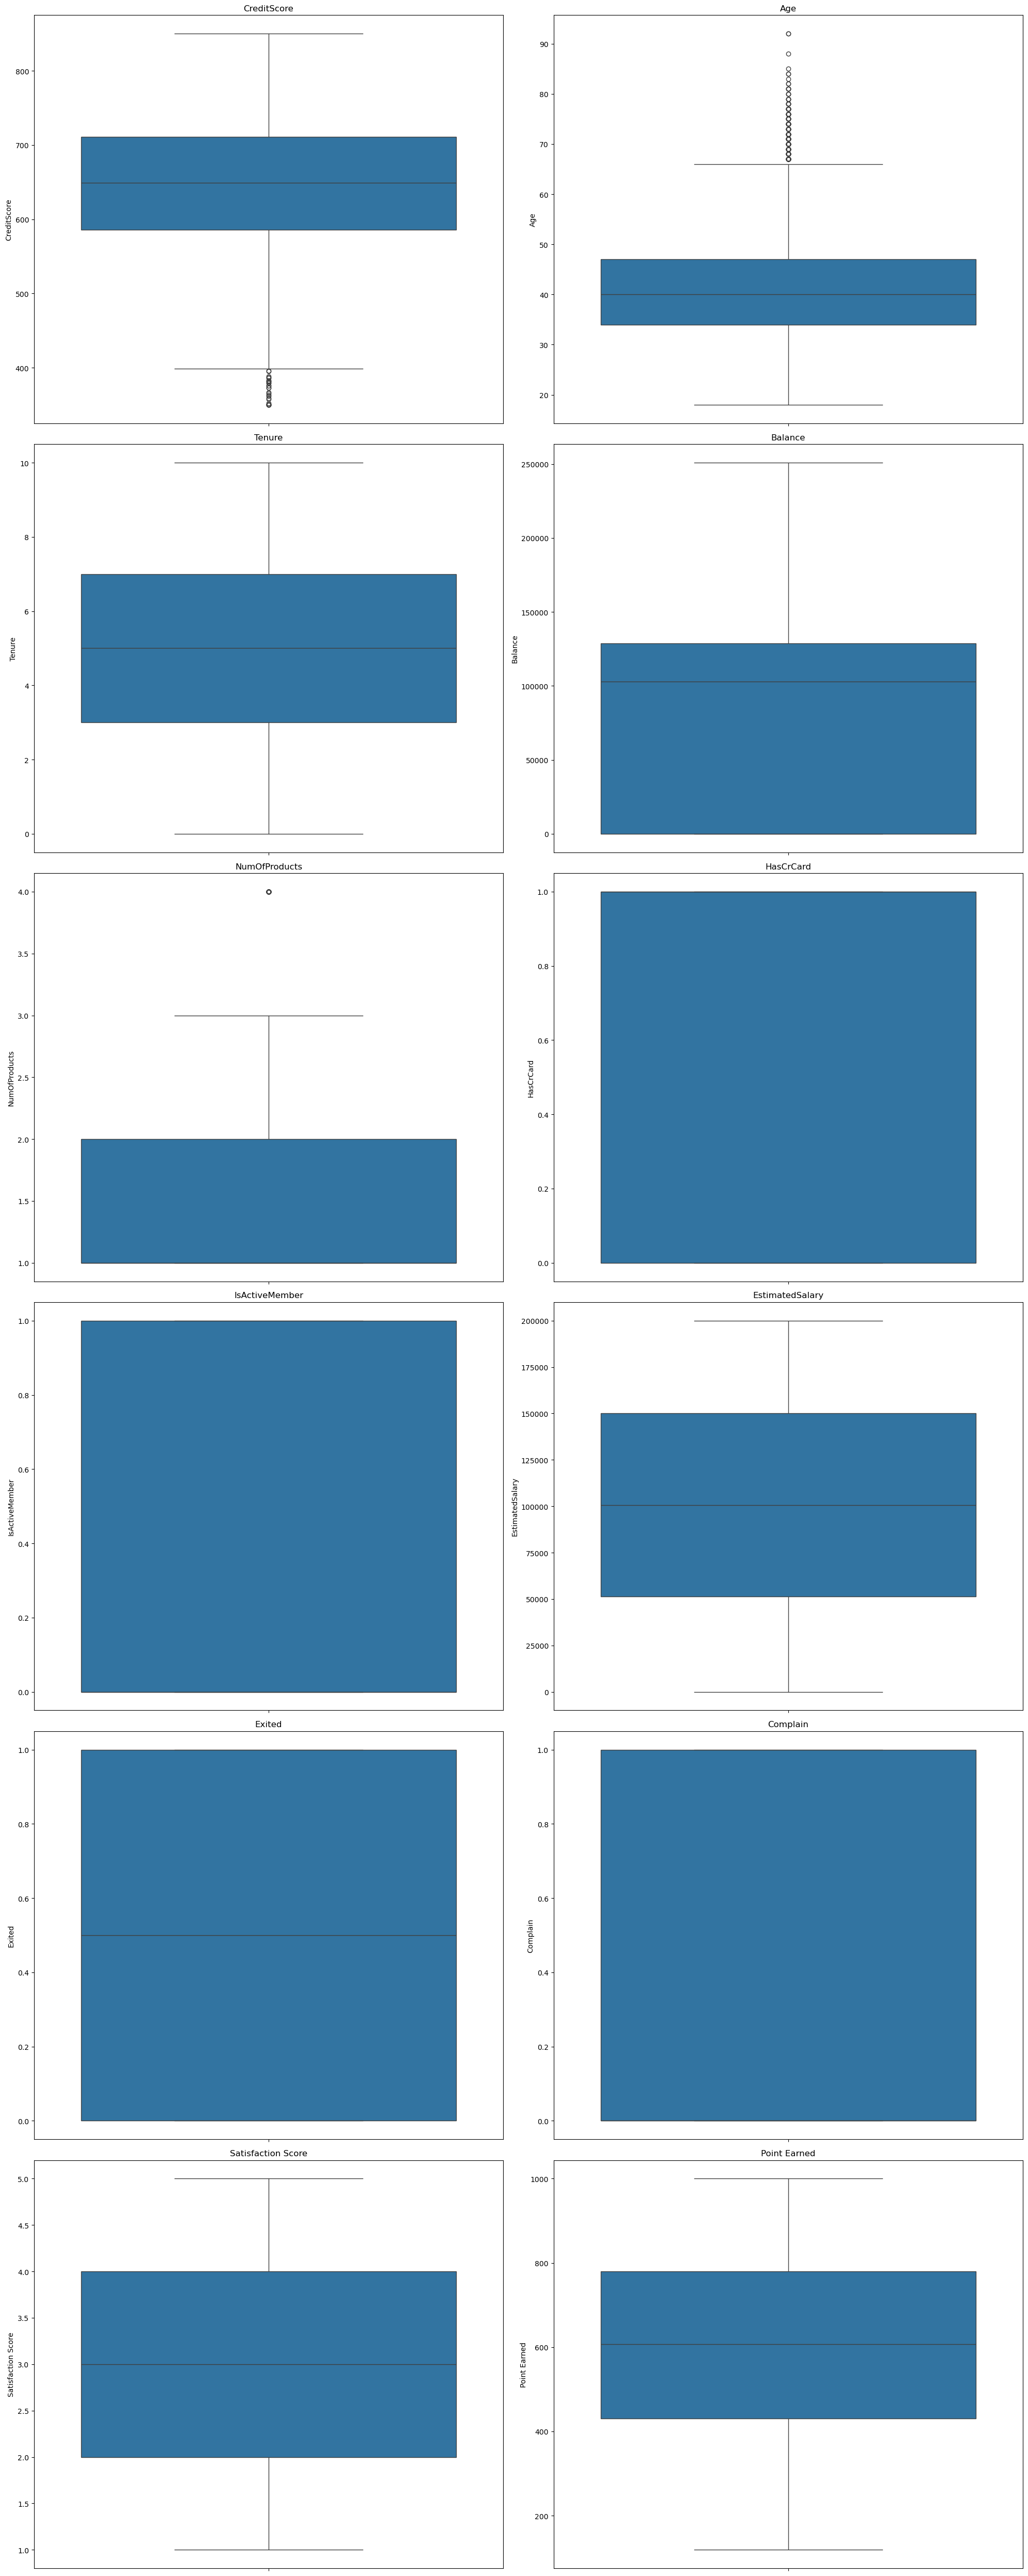

In [89]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.boxplot(df2[column],
                 ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

### IQR

In [120]:
outlier_suspect_col = ['CreditScore', 'Age', 'NumOfProducts']
for col in outlier_suspect_col:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    IQR = q3 - q1
    lower_b = q1 - (IQR * 2)
    upper_b = q3 + (IQR * 2)
    print(f'{col}:')
    print(f'upper_bond = {upper_b}:')
    print(f'lower_bond = {lower_b}:')
    print('\n')
    

CreditScore:
upper_bond = 986.0:
lower_bond = 316.0:


Age:
upper_bond = 68.0:
lower_bond = 8.0:


NumOfProducts:
upper_bond = 4.0:
lower_bond = -1.0:




## กรอง Outlier

In [121]:
creditscore_condition = ((df2['CreditScore'] >= 316.0) & (df2['CreditScore'] <= 986.0))
age_condition = ((df2['Age'] >= 8.0) & (df2['Age'] <= 68.0))
numofproducts_condition = ((df2['NumOfProducts'] >= -1.0) & (df2['NumOfProducts'] <= 4.0))

In [129]:
df2_no_outlier = df2[
    creditscore_condition & age_condition & numofproducts_condition
]

In [130]:
df2_no_outlier.shape

(15739, 21)

In [131]:
df2_no_outlier['Exited'].value_counts()

Exited
1    7933
0    7806
Name: count, dtype: int64

## แสดง Visualize

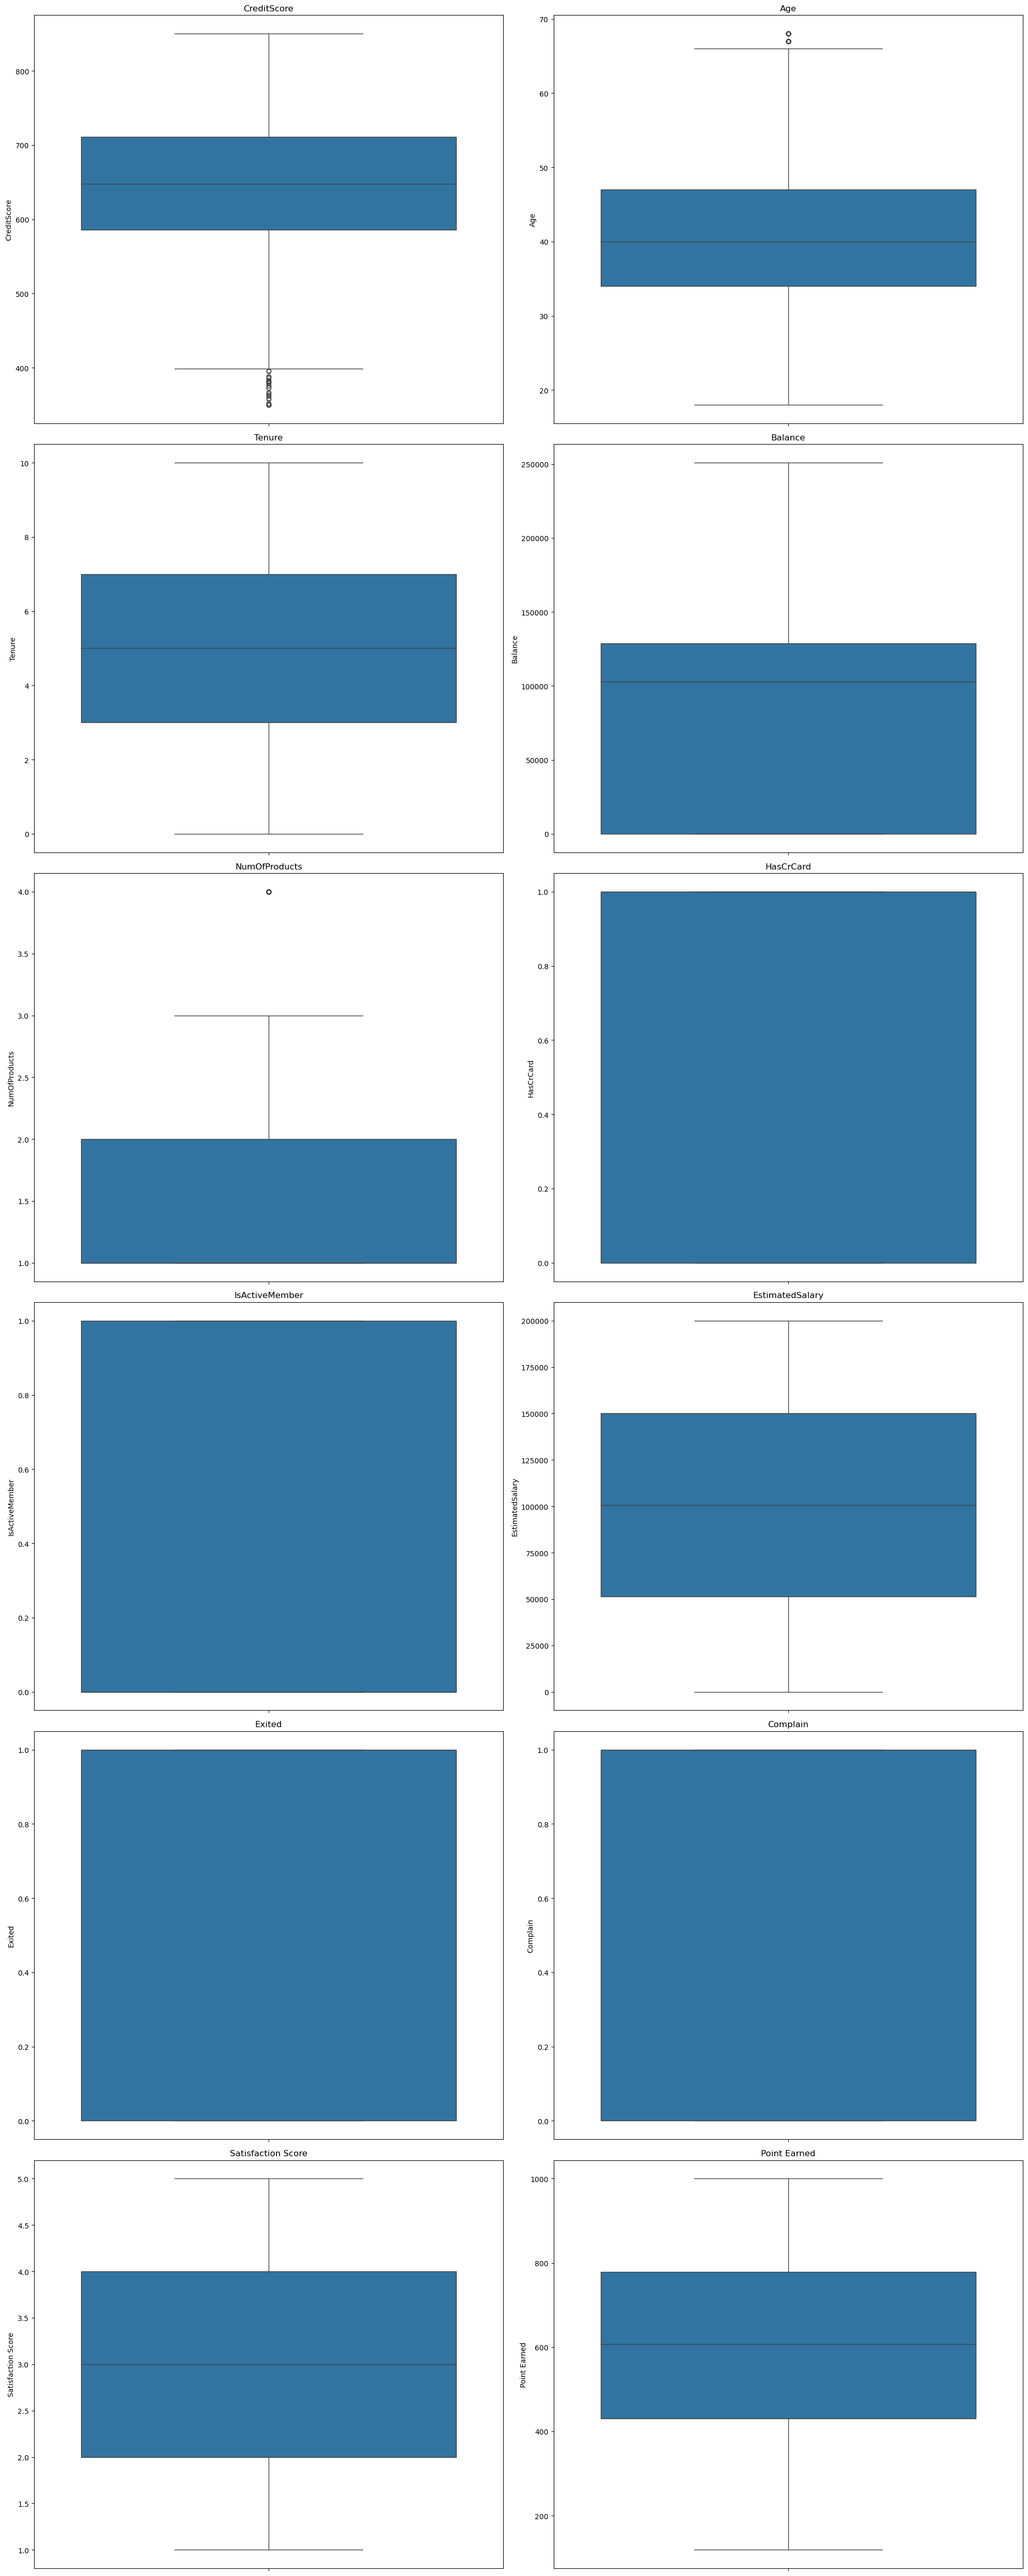

In [132]:
fig, axes = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=[20, 50])
for i, column in enumerate(numerical_col):
    row, col = divmod(i, 2)
    # axes[row, col].hist(df[column])
    sns.boxplot(df2_no_outlier[column],
                 ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

In [133]:
df2_no_outlier.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,...,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Exited
0,619,42,2,0.00,1,1,1,101348.88,1,2,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1
1,608,41,1,83807.86,1,0,1,112542.58,1,3,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0
2,502,42,8,159660.80,3,1,0,113931.57,1,3,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1
3,699,39,1,0.00,2,0,0,93826.63,0,5,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,5,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0


# Insight

## ดูช่วงอายุที่ Exited

In [144]:
df2_no_outlier['Age'].describe()

count    15739.000000
mean        40.628820
std          9.465549
min         18.000000
25%         34.000000
50%         40.000000
75%         47.000000
max         68.000000
Name: Age, dtype: float64

In [147]:
bins = [0, 20, 40, 60, 80]  # กำหนดช่วง
labels = ['0-20', '21-40', '41-60', '61-80']  # ชื่อช่วง
df2_no_outlier['Binned-Age'] = pd.cut(df2_no_outlier['Age'],
                                     bins=bins,
                                     labels=labels,
                                     right=True)

In [152]:
df2_no_outlier.groupby(['Binned-Age'])['Exited'].value_counts()

Binned-Age  Exited
0-20        0           84
            1           11
21-40       0         5648
            1         2537
41-60       1         5166
            0         1881
61-80       1          219
            0          193
Name: count, dtype: int64

In [ ]:
print("eiei why r u seeking")